# Ensemble Learning 02 (1/2) — Voting Ensemble: Classification

### Core idea
Train several **different** classifiers on the **same** data, then let them vote.

| | How the final class is chosen |
|---|---|
| **Hard voting** | each model votes for a **class label**; the majority wins |
| **Soft voting** | average each model's **predicted probabilities**; the class with the highest average wins |

### In this notebook
1. Hard vs soft voting by hand
2. Voting on a curved dataset
3. A real (hard) dataset: when voting does **not** help, and **weights**
4. Same algorithm, different hyperparameters: 5 SVMs voting

> 📖 Theory: [`theory.md`](theory.md) §1 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
CMAP = ListedColormap(['#FA8072', '#1E90FF'])

> ℹ️ **Note for scikit-learn 1.9+:** `SVC(probability=True)` still works but prints a deprecation warning (it will
> later be replaced by `CalibratedClassifierCV`). We hide that one warning below so the output stays readable.

## 1. Hard vs soft voting by hand

Three models predict the probability of **class 1** for one example:

> ✍️ **Core code: learn this.** The two voting rules in a few lines of NumPy.

In [2]:
p_class1 = np.array([0.45, 0.45, 0.99])          # model 1, model 2, model 3

hard_votes = (p_class1 >= 0.5).astype(int)        # each model's label
print("Labels from each model :", hard_votes)
print("HARD voting (majority) :", np.bincount(hard_votes).argmax())

print("\nAverage P(class 1)     :", p_class1.mean().round(2))
print("SOFT voting            :", int(p_class1.mean() >= 0.5))

Labels from each model : [0 0 1]
HARD voting (majority) : 0

Average P(class 1)     : 0.63
SOFT voting            : 1


- **Hard voting** says **0**: two models (barely) prefer class 0.
- **Soft voting** says **1**: model 3 is *very* confident (0.99), while models 1 and 2 are almost undecided (0.45).
  The average probability is 0.63 for class 1.

Soft voting uses **how confident** each model is, so it usually works better, but it requires every model to output
probabilities (for `SVC` set `probability=True`). Try both.

## 2. Voting on a curved dataset

> ✍️ **Core code: learn this.** `VotingClassifier` takes a list of `(name, model)` pairs.

In [3]:
import warnings
warnings.filterwarnings('ignore', message='.*probability.*')   # see the note at the top

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

estimators = [
    ('lr', LogisticRegression()),
    ('svc', SVC(probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)),
]

for name, model in estimators:
    print(f"{name:>4}: {model.fit(X_train, y_train).score(X_test, y_test):.3f}")

hard = VotingClassifier(estimators, voting='hard').fit(X_train, y_train)
soft = VotingClassifier(estimators, voting='soft').fit(X_train, y_train)
print(f"hard: {hard.score(X_test, y_test):.3f}")
print(f"soft: {soft.score(X_test, y_test):.3f}")

  lr: 0.860
 svc: 0.907
  rf: 0.907


hard: 0.907
soft: 0.927


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

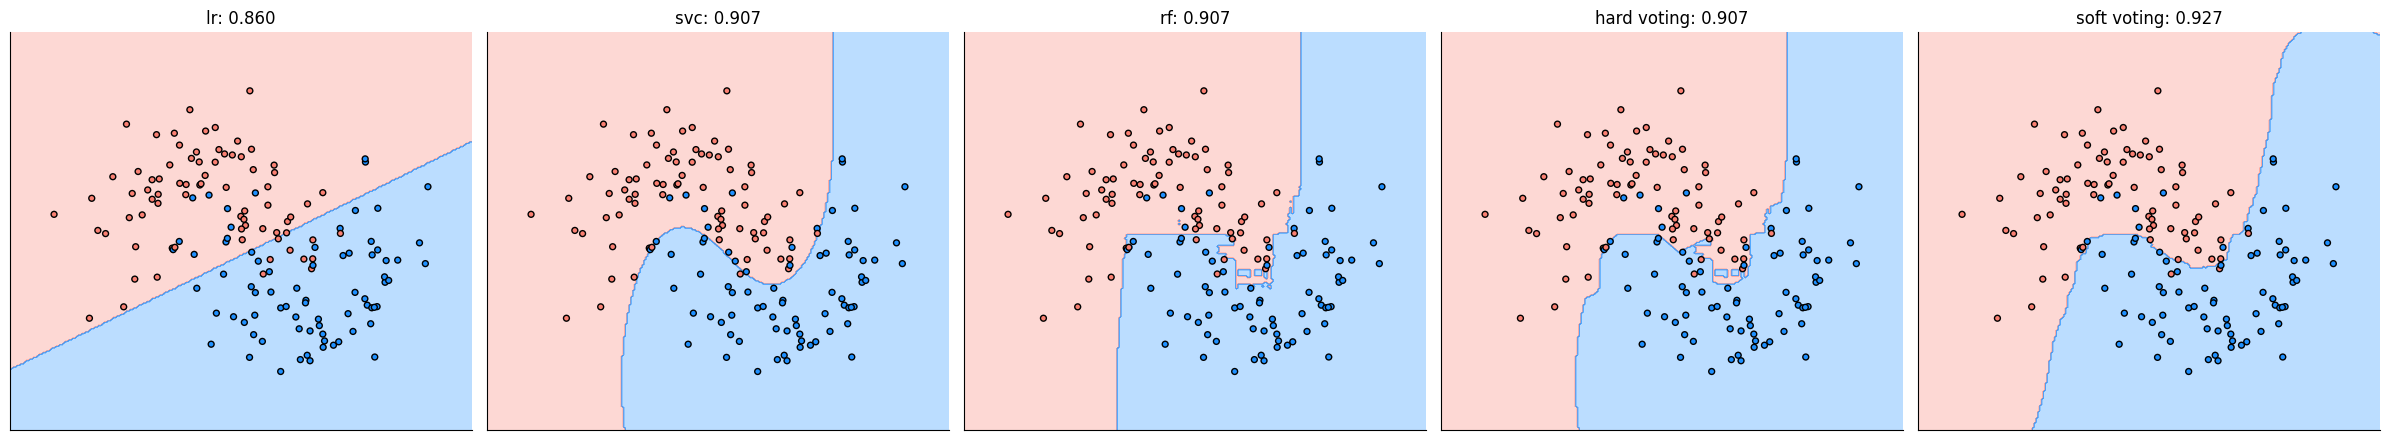

In [4]:
def plot_boundary(ax, model, X, y, title=''):
    # Colour each point of a grid by the model's prediction, then draw the data on top.
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    A, B = np.meshgrid(x0, x1)
    Z = model.predict(np.c_[A.ravel(), B.ravel()]).reshape(A.shape)
    ax.contourf(A, B, Z, alpha=0.3, cmap=CMAP)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolor='k', s=18)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
for ax, (name, m) in zip(axes, estimators):
    plot_boundary(ax, m, X_test, y_test, f'{name}: {m.score(X_test, y_test):.3f}')
plot_boundary(axes[3], hard, X_test, y_test, f'hard voting: {hard.score(X_test, y_test):.3f}')
plot_boundary(axes[4], soft, X_test, y_test, f'soft voting: {soft.score(X_test, y_test):.3f}')
plt.tight_layout()
plt.show()

Logistic regression alone cannot follow the curve. Combined with the SVM and the forest, its straight line is
outvoted where it is wrong. Here **soft voting (0.927) beats every single model** (best: 0.907), and hard voting ties
the best ones.

## 3. A hard dataset: Iris, versicolor vs virginica, 2 features

To make the problem difficult we use only **sepal length and sepal width** and only the two overlapping species.
We judge every model with **10-fold cross-validation** (more reliable than a single split on 100 rows).

In [5]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
mask = iris.target != 0                           # drop setosa (the easy class)
X_iris = iris.data[mask][:, :2]                   # sepal length, sepal width
y_iris = iris.target[mask]
print(X_iris.shape, np.bincount(y_iris)[1:])

(100, 2) [50 50]


> ✍️ **Core code: learn this.** Compare each model and both voting styles with cross-validation.

In [6]:
estimators = [
    ('lr', LogisticRegression()),
    ('rf', RandomForestClassifier(random_state=0)),
    ('knn', KNeighborsClassifier()),
]
for name, model in estimators:
    print(f"{name:>4}: {cross_val_score(model, X_iris, y_iris, cv=10).mean():.3f}")

for voting in ['hard', 'soft']:
    score = cross_val_score(VotingClassifier(estimators, voting=voting), X_iris, y_iris, cv=10).mean()
    print(f"{voting}: {score:.3f}")

  lr: 0.750


  rf: 0.620
 knn: 0.620


hard: 0.680


soft: 0.650


**Honest result:** logistic regression alone (0.75) beats both voting ensembles. The random forest and KNN are much
weaker here (0.62), and with equal votes they drag the ensemble down.

> Voting is **not** guaranteed to win. Always compare against the best single model.

### Weights: not every vote has to count equally
`weights=[w1, w2, w3]` gives better models a louder voice. We try every combination of weights 1–3:

> ✍️ **Core code: learn this.** Search for good weights.

In [7]:
results = []
for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            vc = VotingClassifier(estimators, voting='soft', weights=[i, j, k])
            results.append({'weights (lr, rf, knn)': (i, j, k),
                            'accuracy': cross_val_score(vc, X_iris, y_iris, cv=10).mean()})

pd.DataFrame(results).sort_values('accuracy', ascending=False).head(5).round(3)

,"weights (lr, rf, knn)",accuracy
18,"(3, 1, 1)",0.71
20,"(3, 1, 3)",0.70
19,"(3, 1, 2)",0.69
21,"(3, 2, 1)",0.68
9,"(2, 1, 1)",0.68


Giving logistic regression the biggest weight (3, 1, 1) lifts the ensemble to about **0.71**. The ensemble is "no
longer a democracy": the best model's vote counts most. (Here LR alone is still slightly better, which confirms that the
other two models add little on this dataset.)

## 4. Same algorithm, different settings: five SVMs

Diversity does not have to come from different algorithms. Here: **5 SVMs**, each with a different polynomial degree.

> ✍️ **Core code: learn this.** One algorithm, five hyperparameter settings, one vote.

In [8]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svms = [(f'svm_degree_{d}', SVC(kernel='poly', degree=d, probability=True, random_state=0)) for d in range(1, 6)]

for name, model in svms:
    print(f"{name}: {cross_val_score(model, X, y, cv=10).mean():.3f}")

ensemble = VotingClassifier(svms, voting='soft')
print(f"\nSoft-voting ensemble of all 5: {cross_val_score(ensemble, X, y, cv=10).mean():.3f}")

svm_degree_1: 0.854


svm_degree_2: 0.853


svm_degree_3: 0.894


svm_degree_4: 0.809


svm_degree_5: 0.864



Soft-voting ensemble of all 5: 0.926


The ensemble (**0.926**) beats **every** single SVM; the best one alone scores 0.894. Instead of agonising over which
degree is best, let them vote.

---
## Key takeaways
- **Hard voting** = majority of labels; **soft voting** = highest average probability (usually better; try both).
- Base models should be **diverse** and each better than random guessing.
- Voting does **not** always beat the best single model: compare with cross-validation.
- `weights` let stronger models count more.
- Diversity can also come from the **same algorithm with different hyperparameters**.

## 🧠 Quick check

<details><summary>1. Model probabilities for class 1 are 0.45, 0.45 and 0.99. Hard and soft predictions?</summary>

Hard: 0 (two of three labels are 0). Soft: 1 (average probability 0.63).
</details>

<details><summary>2. What does SVC need for soft voting?</summary>

`probability=True`, so it can output class probabilities.
</details>

<details><summary>3. On Iris, LR alone beat the ensemble. Why?</summary>

The other two models were much weaker on this data; with equal votes they pulled the ensemble down.
</details>

➡️ **Next:** [`02-voting-regressor.ipynb`](02-voting-regressor.ipynb)